# XGBoost model

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_parquet("../data/final_merged_dataset.parquet")
df = df.sort_values("datetime_hour").reset_index(drop=True)

In [3]:
print(df.dtypes.value_counts())
print(df.shape)

float64           448
int64               7
str                 4
bool                4
datetime64[us]      1
object              1
Name: count, dtype: int64
(853536, 465)


In [4]:
print("str cols:", df.select_dtypes(include='object').columns.tolist())
print("bool cols:", df.select_dtypes(include='bool').columns.tolist())
print("datetime cols:", df.select_dtypes(include='datetime64').columns.tolist())

str cols: ['city_name', 'day_datetime', 'day_sunrise', 'day_sunset', 'region_key']
bool cols: ['hour_conditions_simple_Clear', 'hour_conditions_simple_Cloudy', 'hour_conditions_simple_Rain', 'hour_conditions_simple_Snow']
datetime cols: ['datetime_hour']


C:\Users\Uw11\AppData\Local\Temp\ipykernel_19852\1106464062.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("str cols:", df.select_dtypes(include='object').columns.tolist())


In [5]:
y = df['alarm_active']
X = df.drop(columns=['datetime_hour', 'alarm_active', 'alarm_minutes_in_hour', 'region_key', 'day_datetime', 'day_sunrise', 'day_sunset'], errors="ignore")

In [6]:
X = X.select_dtypes(include=["number", "bool"]).copy()
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype("int8")

In [7]:
split_index = int(len(X) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [8]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

In [9]:
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target balance train: {y_train.mean():.2%}")
print(f"Target balance test: {y_test.mean():.2%}")

Train: (682828, 457), Test: (170708, 457)
Target balance train: 19.02%
Target balance test: 30.83%


In [10]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 4.26


In [11]:
tscv = TimeSeriesSplit(n_splits=3)

In [12]:
param_grid = [
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 6, 
     "subsample": 0.8, "reg_lambda": 1.0, "reg_alpha": 0.0},
    
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 8, 
     "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0, "reg_alpha": 0.0},
    
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 8, 
     "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 3.0, "reg_alpha": 0.5},
    
    {"n_estimators": 600, "learning_rate": 0.03, "max_depth": 8, 
     "subsample": 0.8, "reg_lambda": 2.0, "reg_alpha": 0.0},
]

best_score = -np.inf
best_params = None

for params in param_grid:
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = xgb.XGBClassifier(
            **params,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            eval_metric="auc"
        )
        model.fit(X_tr, y_tr)
        y_val_proba = model.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, y_val_proba)
        scores.append(score)

    mean_score = np.mean(scores)
    print(f"{params} -> ROC-AUC: {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_params = params

print(f"\nBest params: {best_params}")
print(f"Best ROC-AUC: {best_score:.4f}")

{'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0} -> ROC-AUC: 0.8880
{'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 8, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0} -> ROC-AUC: 0.8894
{'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 8, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 3.0, 'reg_alpha': 0.5} -> ROC-AUC: 0.8901
{'n_estimators': 600, 'learning_rate': 0.03, 'max_depth': 8, 'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.0} -> ROC-AUC: 0.8892

Best params: {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 8, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 3.0, 'reg_alpha': 0.5}
Best ROC-AUC: 0.8901


In [13]:
xgb_model = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    eval_metric="auc"
)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [14]:
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

In [15]:
print("\n--- Default threshold (0.5) ---")
print(classification_report(y_test, y_pred, target_names=["No alarm", "Alarm"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

threshold = 0.4
y_pred_custom = (y_proba >= threshold).astype(int)
print(f"\n--- Custom threshold ({threshold}) ---")
print(classification_report(y_test, y_pred_custom, target_names=["No alarm", "Alarm"]))


--- Default threshold (0.5) ---
              precision    recall  f1-score   support

    No alarm       0.95      0.85      0.90    118084
       Alarm       0.73      0.90      0.80     52624

    accuracy                           0.86    170708
   macro avg       0.84      0.87      0.85    170708
weighted avg       0.88      0.86      0.87    170708

ROC-AUC: 0.9415128004771564
PR-AUC: 0.8817706376976806

--- Custom threshold (0.4) ---
              precision    recall  f1-score   support

    No alarm       0.96      0.79      0.87    118084
       Alarm       0.67      0.93      0.78     52624

    accuracy                           0.83    170708
   macro avg       0.81      0.86      0.82    170708
weighted avg       0.87      0.83      0.84    170708



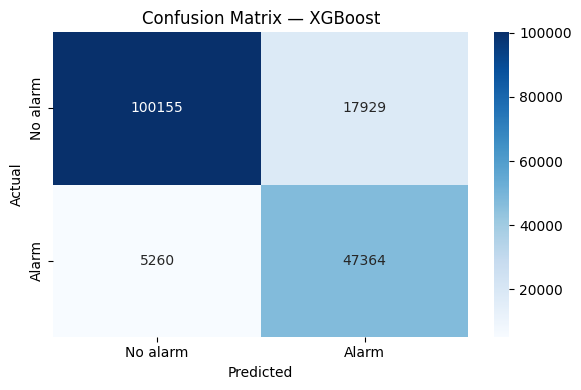

In [16]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No alarm", "Alarm"],
            yticklabels=["No alarm", "Alarm"])
plt.title("Confusion Matrix — XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

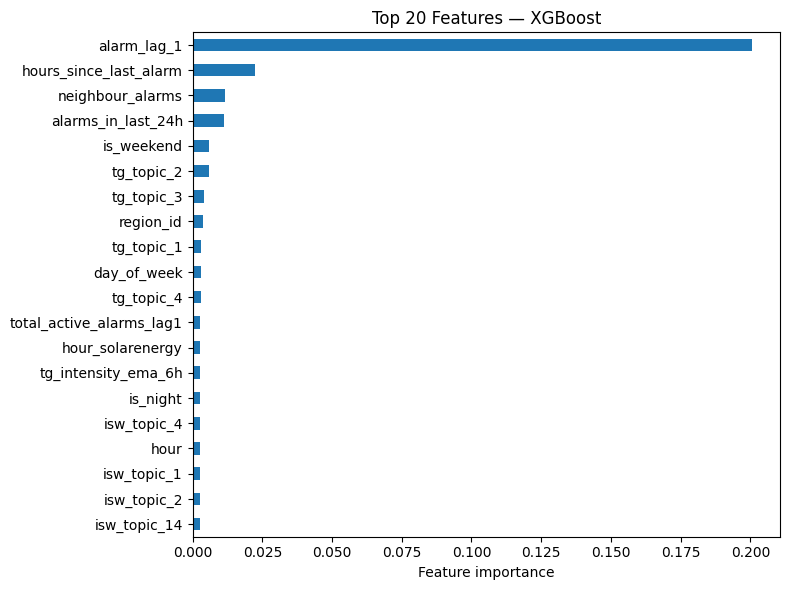

In [17]:
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=False).head(20)

top20.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 20 Features — XGBoost")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

In [18]:
#with open("xgboost_model.pkl", "wb") as f:
#    pickle.dump(xgboost_model, f)
#print("Model saved: xgboost_model.pkl")